# Кейс 6. Метрические методы регрессии

Исследовательская работа по дисциплине «Функциональный анализ». Автор: Мирасов К. В., группа J3212.

## Введение

Рассматривается задача непараметрической регрессии при гипотезе непрерывности: близким по метрике объектам соответствуют близкие ответы. Значение регрессии в новой точке восстанавливается по локальному окружению обучающей выборки $X^\ell = \{(x_i, y_i)\}_{i=1}^{\ell}$, где $x_i \in \mathbb{R}^n$, $y_i \in \mathbb{R}$, без введения конечномерной параметрической модели.

Цель работы состоит в реализации с нуля и исследовании трёх методов:

1. оценки Надарая–Ватсона с фиксированным окном;
2. оценки Надарая–Ватсона с переменным окном;
3. робастной схемы LOWESS.

Изучается влияние формы ядра, ширины окна $h$, числа соседей $k$ и робастного перевзвешивания на ошибку прогноза и устойчивость к выбросам. Каждый рисунок строится в ноутбуке и одновременно сохраняется в `reports/case6_metric_regression/assets/` для отчёта.


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Callable
import json

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

SEED: int = 42
EPS: float = 1e-12
N_SYNTH: int = 180
N_GRID: int = 420
SYNTH_NOISE: float = 0.12
LOWESS_ITERATIONS: int = 5
REAL_SAMPLE_SIZE: int = 1200
OUTLIER_FRACTION: float = 0.15
OUTLIER_SCALE: float = 3.8
CONTAMINATION_LEVELS: np.ndarray = np.array([0.0, 0.05, 0.10, 0.15, 0.20, 0.30])
CONTAMINATION_REPEATS: int = 4

ROOT_DIR: Path = Path.cwd()
if not (ROOT_DIR / "pyproject.toml").exists():
    ROOT_DIR = ROOT_DIR.parent
ASSETS_DIR: Path = ROOT_DIR / "reports" / "case6_metric_regression" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

Kernel = Callable[[np.ndarray], np.ndarray]

PALETTE: dict[str, str] = {
    "data":  "#9aa0a6",
    "truth": "#1f4e79",
    "model": "#c1121f",
    "alt":   "#5a7d2a",
    "extra": "#b8860b",
}

mpl.rcParams.update({
    "figure.figsize":     (7.0, 4.2),
    "figure.dpi":         120,
    "savefig.dpi":        200,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.03,
    "svg.fonttype":       "path",
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":   "cm",
    "font.size":          11,
    "axes.titlesize":     12,
    "axes.labelsize":     11,
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "legend.frameon":     False,
    "legend.fontsize":    10,
    "lines.linewidth":    1.8,
    "lines.markersize":   4,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
})


def save_fig(fig: plt.Figure, name: str, *, raster: bool = False) -> None:
    """Save a figure to the report assets directory and show it inline."""
    ext = "png" if raster else "svg"
    fig.savefig(ASSETS_DIR / f"{name}.{ext}")
    display(fig)
    plt.close(fig)


def save_table(df: pd.DataFrame, name: str) -> None:
    """Save a table artifact to the report assets directory as CSV."""
    df.to_csv(ASSETS_DIR / f"{name}.csv", index=False)


## Ядра сглаживания

Ядро $K(r)$ задаёт убывание веса наблюдения с ростом расстояния. Рассматриваются четыре ядра:

$$
K_{\mathrm{G}}(r) = e^{-r^2/2}, \qquad
K_{\mathrm{E}}(r) = \tfrac{3}{4}(1 - r^2)_+, \qquad
K_{\mathrm{Q}}(r) = \tfrac{15}{16}(1 - r^2)_+^2, \qquad
K_{\mathrm{T}}(r) = (1 - r)_+,
$$

где $(u)_+ = \max(u, 0)$. Гауссовское ядро имеет бесконечный носитель, остальные финитны и зануляют объекты вне единичного радиуса. В оценке Надарая–Ватсона общий множитель ядра сокращается, поэтому значима форма убывания веса, а не нормировочная константа.


In [2]:
def gaussian_kernel(r: np.ndarray) -> np.ndarray:
    """Gaussian kernel K(r) = exp(-r^2 / 2)."""
    return np.exp(-0.5 * np.square(r))


def epanechnikov_kernel(r: np.ndarray) -> np.ndarray:
    """Epanechnikov kernel K(r) = 0.75 (1 - r^2) on [0, 1]."""
    positive = np.maximum(1.0 - np.square(r), 0.0)
    return 0.75 * positive * (r <= 1.0)


def quartic_kernel(r: np.ndarray) -> np.ndarray:
    """Quartic kernel K(r) = (15/16)(1 - r^2)^2 on [0, 1]."""
    positive = np.maximum(1.0 - np.square(r), 0.0)
    return (15.0 / 16.0) * np.square(positive) * (r <= 1.0)


def triangular_kernel(r: np.ndarray) -> np.ndarray:
    """Triangular kernel K(r) = 1 - r on [0, 1]."""
    return np.maximum(1.0 - r, 0.0) * (r <= 1.0)


KERNELS: dict[str, Kernel] = {
    "gaussian": gaussian_kernel,
    "epanechnikov": epanechnikov_kernel,
    "quartic": quartic_kernel,
    "triangular": triangular_kernel,
}

KERNEL_LABELS: dict[str, str] = {
    "gaussian": "Гауссовское",
    "epanechnikov": "Епанечникова",
    "quartic": "Квартическое",
    "triangular": "Треугольное",
}


## Метрика и нормировка весов

Расстояние между объектами евклидово, $\rho(x, x_i) = \lVert x - x_i \rVert_2$; признаки предварительно стандартизируются по обучающей части. Веса наблюдений нормируются построчно:

$$
\tilde{w}_i(x) = \frac{w_i(x)}{\sum_{j=1}^{\ell} w_j(x)}, \qquad \sum_{i=1}^{\ell} \tilde{w}_i(x) = 1.
$$

Для финитных ядер при нулевой сумме весов в качестве численной защиты используется ближайший сосед. При скользящем контроле объект исключается из собственной окрестности обнулением диагонали весовой матрицы.


In [3]:
def ensure_2d(X: np.ndarray) -> np.ndarray:
    """Return X as a two-dimensional float array."""
    array = np.asarray(X, dtype=float)
    if array.ndim == 1:
        return array.reshape(-1, 1)
    return array


def pairwise_distances(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Return the Euclidean distance matrix with shape (len(A), len(B))."""
    A2 = ensure_2d(A)
    B2 = ensure_2d(B)
    squared = (
        np.sum(np.square(A2), axis=1, keepdims=True)
        + np.sum(np.square(B2), axis=1)[None, :]
        - 2.0 * A2 @ B2.T
    )
    return np.sqrt(np.maximum(squared, 0.0))


def normalize_weights(weights: np.ndarray) -> np.ndarray:
    """Normalize rows of a nonnegative weight matrix when row sums are positive."""
    denominator = weights.sum(axis=1, keepdims=True)
    return np.divide(weights, denominator, out=np.zeros_like(weights), where=denominator > EPS)


def _fallback_indices(distances: np.ndarray) -> np.ndarray:
    """Return nearest-neighbor indices for zero-denominator fallback predictions."""
    return np.argmin(distances, axis=1)


## Оценка Надарая–Ватсона

Для фиксированного окна $h > 0$ оценка регрессии является нормированным взвешенным средним ответов:

$$
a(x; X^\ell, h) = \frac{\sum_{i=1}^{\ell} y_i\, K\!\big(\rho(x, x_i)/h\big)}{\sum_{i=1}^{\ell} K\!\big(\rho(x, x_i)/h\big)}.
$$

Переменное окно задаётся расстоянием до $(k{+}1)$-го соседа $h(x) = \rho(x, x_{(k+1)})$, поэтому окно сужается в плотных областях и расширяется в разреженных:

$$
a(x; X^\ell, k) = \frac{\sum_{i=1}^{\ell} y_i\, K\!\big(\rho(x, x_i)/\rho(x, x_{(k+1)})\big)}{\sum_{i=1}^{\ell} K\!\big(\rho(x, x_i)/\rho(x, x_{(k+1)})\big)}.
$$

**Связь с локально взвешенным МНК.** Оценка получается из задачи $Q(\theta; x) = \sum_i w_i (\theta - y_i)^2 \to \min_\theta$ с весами $w_i = K(\rho(x, x_i)/h)$. Условие стационарности $\sum_i w_i (\theta - y_i) = 0$ даёт

$$
\theta^\ast = \frac{\sum_i w_i y_i}{\sum_i w_i},
$$

что совпадает с формулой Надарая–Ватсона. Ядерное сглаживание есть решение локальной вариационной задачи с константной аппроксимацией функции в окрестности точки $x$.


In [4]:
def nadaraya_watson_fixed(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_query: np.ndarray,
    h: float,
    kernel: Kernel,
) -> np.ndarray:
    """Predict with fixed-bandwidth Nadaraya-Watson regression."""
    if h <= 0:
        raise ValueError("h must be positive")
    X_train_2d = ensure_2d(X_train)
    X_query_2d = ensure_2d(X_query)
    y = np.asarray(y_train, dtype=float)
    distances = pairwise_distances(X_query_2d, X_train_2d)
    weights = kernel(distances / max(float(h), EPS))
    denominator = weights.sum(axis=1)
    prediction = weights @ y / np.maximum(denominator, EPS)
    zero_rows = denominator <= EPS
    if np.any(zero_rows):
        prediction[zero_rows] = y[_fallback_indices(distances[zero_rows])]
    return prediction


def nadaraya_watson_adaptive(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_query: np.ndarray,
    k: int,
    kernel: Kernel,
) -> np.ndarray:
    """Predict with adaptive-window Nadaraya-Watson regression."""
    X_train_2d = ensure_2d(X_train)
    X_query_2d = ensure_2d(X_query)
    y = np.asarray(y_train, dtype=float)
    if len(X_train_2d) == 0:
        raise ValueError("X_train must not be empty")
    distances = pairwise_distances(X_query_2d, X_train_2d)
    order_index = min(max(int(k), 0), len(X_train_2d) - 1)
    bandwidths = np.partition(distances, order_index, axis=1)[:, order_index]
    bandwidths = np.maximum(bandwidths, EPS)
    weights = kernel(distances / bandwidths[:, None])
    denominator = weights.sum(axis=1)
    prediction = weights @ y / np.maximum(denominator, EPS)
    zero_rows = denominator <= EPS
    if np.any(zero_rows):
        prediction[zero_rows] = y[_fallback_indices(distances[zero_rows])]
    return prediction


## Скользящий контроль и подбор окна

Гиперпараметр $\lambda$ (ширина $h$ либо число соседей $k$) выбирается по скользящему контролю с исключением одного объекта:

$$
\mathrm{RMSE}_{\mathrm{LOO}}(\lambda) = \sqrt{\frac{1}{\ell} \sum_{i=1}^{\ell} \big(y_i - a_{-i}(x_i; \lambda)\big)^2},
$$

где $a_{-i}$ вычисляется без участия объекта $i$. Для фиксированного окна используется логарифмическая сетка $h$ по квантилям положительных попарных расстояний; для переменного окна применяется целочисленная сетка $k$.


In [5]:
def loo_weight_matrix_fixed(X: np.ndarray, h: float, kernel: Kernel) -> np.ndarray:
    """Return fixed-window LOO weights with a zero diagonal."""
    distances = pairwise_distances(X, X)
    weights = kernel(distances / max(float(h), EPS))
    np.fill_diagonal(weights, 0.0)
    return weights


def loo_predict_fixed(X: np.ndarray, y: np.ndarray, h: float, kernel: Kernel) -> np.ndarray:
    """Leave-one-out predictions for fixed-window Nadaraya-Watson regression."""
    y_array = np.asarray(y, dtype=float)
    weights = loo_weight_matrix_fixed(X, h, kernel)
    denominator = weights.sum(axis=1)
    prediction = weights @ y_array / np.maximum(denominator, EPS)
    zero_rows = denominator <= EPS
    if np.any(zero_rows):
        loo_mean = (np.sum(y_array) - y_array) / max(len(y_array) - 1, 1)
        prediction[zero_rows] = loo_mean[zero_rows]
    return prediction


def _adaptive_loo_bandwidths(distances: np.ndarray, k: int) -> np.ndarray:
    """Return adaptive LOO bandwidths after excluding self-distances."""
    n_samples = distances.shape[0]
    masked = distances.copy()
    np.fill_diagonal(masked, np.inf)
    if n_samples <= 2:
        finite = np.where(np.isfinite(masked), masked, EPS)
        return np.maximum(np.min(finite, axis=1), EPS)
    order_index = min(max(int(k), 0), n_samples - 2)
    bandwidths = np.partition(masked, order_index, axis=1)[:, order_index]
    return np.maximum(bandwidths, EPS)


def _loo_predict_adaptive_weighted(
    X: np.ndarray,
    y: np.ndarray,
    k: int,
    kernel: Kernel,
    gamma: np.ndarray,
) -> np.ndarray:
    """Return adaptive LOO predictions with external object weights gamma."""
    y_array = np.asarray(y, dtype=float)
    gamma_array = np.asarray(gamma, dtype=float)
    distances = pairwise_distances(X, X)
    bandwidths = _adaptive_loo_bandwidths(distances, k)
    weights = kernel(distances / bandwidths[:, None]) * gamma_array[None, :]
    np.fill_diagonal(weights, 0.0)
    denominator = weights.sum(axis=1)
    prediction = weights @ y_array / np.maximum(denominator, EPS)
    zero_rows = denominator <= EPS
    if np.any(zero_rows):
        loo_mean = (np.sum(y_array) - y_array) / max(len(y_array) - 1, 1)
        prediction[zero_rows] = loo_mean[zero_rows]
    return prediction


def loo_predict_adaptive(X: np.ndarray, y: np.ndarray, k: int, kernel: Kernel) -> np.ndarray:
    """Leave-one-out predictions for adaptive-window Nadaraya-Watson regression."""
    gamma = np.ones(len(ensure_2d(X)), dtype=float)
    return _loo_predict_adaptive_weighted(X, y, k, kernel, gamma)


def loo_error(
    X: np.ndarray,
    y: np.ndarray,
    param: float,
    kernel: Kernel,
    *,
    adaptive: bool = False,
    metric: str = "rmse",
) -> float:
    """Return LOO error for h or k according to the selected metric."""
    predictions = (
        loo_predict_adaptive(X, y, int(param), kernel)
        if adaptive
        else loo_predict_fixed(X, y, float(param), kernel)
    )
    residual = np.asarray(y, dtype=float) - predictions
    if metric == "rmse":
        return float(np.sqrt(np.mean(np.square(residual))))
    if metric == "mae":
        return float(np.mean(np.abs(residual)))
    raise ValueError("metric must be 'rmse' or 'mae'")


def select_bandwidth(
    X: np.ndarray,
    y: np.ndarray,
    kernel: Kernel,
    grid: np.ndarray,
    *,
    adaptive: bool = False,
) -> tuple[float, np.ndarray]:
    """Select h or k by minimum LOO-RMSE over the supplied grid."""
    params = np.asarray(grid, dtype=float)
    errors = np.array([loo_error(X, y, value, kernel, adaptive=adaptive, metric="rmse") for value in params])
    return float(params[int(np.argmin(errors))]), errors


## Робастная схема LOWESS

LOWESS вводит объектные веса $\gamma_i$, инициализированные единицами. На каждой итерации пересчитываются LOO-прогноз $a_i$, остаток $\varepsilon_i = |a_i - y_i|$ и новые веса по квартическому ядру:

$$
a_i = \frac{\sum_{j \ne i} y_j\, \gamma_j\, K\!\big(\rho(x_i, x_j)/h(x_i)\big)}{\sum_{j \ne i} \gamma_j\, K\!\big(\rho(x_i, x_j)/h(x_i)\big)}, \qquad
\gamma_i = \tilde{K}\!\left(\frac{\varepsilon_i}{6\, \operatorname{med}_j \varepsilon_j}\right).
$$

Объекты с большим относительным остатком получают веса, близкие к нулю. В экспериментах выполняется пять итераций.


In [6]:
def lowess_fit(
    X: np.ndarray,
    y: np.ndarray,
    *,
    k: int,
    kernel: Kernel,
    reweight_kernel: Kernel = quartic_kernel,
    n_iter: int = 4,
) -> tuple[np.ndarray, np.ndarray]:
    """Fit iterative LOWESS and return stabilized gamma and LOO predictions."""
    X_2d = ensure_2d(X)
    y_array = np.asarray(y, dtype=float)
    gamma = np.ones(len(X_2d), dtype=float)
    predictions = np.zeros_like(y_array)
    for _ in range(n_iter):
        predictions = _loo_predict_adaptive_weighted(X_2d, y_array, k, kernel, gamma)
        residual = np.abs(predictions - y_array)
        median_residual = float(np.median(residual))
        if median_residual <= EPS:
            gamma = np.ones_like(gamma)
            break
        updated = reweight_kernel(residual / (6.0 * median_residual))
        if np.max(np.abs(updated - gamma)) < 1e-4:
            gamma = updated
            break
        gamma = updated
    predictions = _loo_predict_adaptive_weighted(X_2d, y_array, k, kernel, gamma)
    return gamma, predictions


def lowess_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_query: np.ndarray,
    gamma: np.ndarray,
    *,
    k: int,
    kernel: Kernel,
) -> np.ndarray:
    """Predict with adaptive Nadaraya-Watson regression using robust gamma weights."""
    X_train_2d = ensure_2d(X_train)
    X_query_2d = ensure_2d(X_query)
    y = np.asarray(y_train, dtype=float)
    gamma_array = np.asarray(gamma, dtype=float)
    distances = pairwise_distances(X_query_2d, X_train_2d)
    order_index = min(max(int(k), 0), len(X_train_2d) - 1)
    bandwidths = np.partition(distances, order_index, axis=1)[:, order_index]
    bandwidths = np.maximum(bandwidths, EPS)
    weights = kernel(distances / bandwidths[:, None]) * gamma_array[None, :]
    denominator = weights.sum(axis=1)
    prediction = weights @ y / np.maximum(denominator, EPS)
    zero_rows = denominator <= EPS
    if np.any(zero_rows):
        prediction[zero_rows] = y[_fallback_indices(distances[zero_rows])]
    return prediction


## Данные и метрики качества

Синтетическая выборка: $\ell = 180$ точек $x \in [0, 2\pi]$ и ответы $y = \sin x + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0{,}12^2)$; для визуализации используется равномерная сетка из 420 точек. Реальные данные: Diabetes (442 объекта целиком) и California Housing (фиксированная подвыборка 1200 объектов из-за сложности $O(\ell^2)$ матрицы расстояний). Качество измеряется в MAE, RMSE и $R^2$.


In [7]:
def sine_function(X: np.ndarray) -> np.ndarray:
    """Return sin(x) for one-dimensional inputs."""
    return np.sin(ensure_2d(X)[:, 0])


def generate_sine_data(
    n_samples: int,
    noise: float,
    rng: np.random.Generator,
    *,
    outlier_fraction: float = 0.0,
    outlier_scale: float = OUTLIER_SCALE,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Generate a one-dimensional sine regression sample with optional outliers."""
    x = np.sort(rng.uniform(0.0, 2.0 * np.pi, size=n_samples))
    X = x.reshape(-1, 1)
    y_clean = sine_function(X)
    y = y_clean + rng.normal(0.0, noise, size=n_samples)
    outlier_mask = np.zeros(n_samples, dtype=bool)
    n_outliers = int(round(outlier_fraction * n_samples))
    if n_outliers > 0:
        indices = rng.choice(n_samples, size=n_outliers, replace=False)
        signs = rng.choice(np.array([-1.0, 1.0]), size=n_outliers)
        y[indices] += signs * outlier_scale * (1.0 + 0.25 * rng.normal(size=n_outliers))
        outlier_mask[indices] = True
    return X, y, y_clean, outlier_mask


def standardize_train_test(X_train: np.ndarray, X_test: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Standardize features using train mean and train standard deviation."""
    train = ensure_2d(X_train)
    test = ensure_2d(X_test)
    mean = train.mean(axis=0, keepdims=True)
    std = train.std(axis=0, keepdims=True)
    std = np.where(std <= EPS, 1.0, std)
    return (train - mean) / std, (test - mean) / std


def make_bandwidth_grid(X: np.ndarray, *, n_values: int = 30) -> np.ndarray:
    """Build a logarithmic bandwidth grid from positive pairwise distances."""
    distances = pairwise_distances(X, X)
    positive = distances[distances > EPS]
    lower = max(float(np.quantile(positive, 0.05)) * 0.35, EPS)
    upper = max(float(np.quantile(positive, 0.90)) * 1.20, lower * 1.5)
    return np.geomspace(lower, upper, n_values)


def make_k_grid(n_samples: int, *, max_k: int = 70, step: int = 2) -> np.ndarray:
    """Return an integer grid for adaptive-window neighbor counts."""
    upper = max(3, min(max_k, n_samples - 3))
    grid = np.arange(2, upper + 1, step, dtype=int)
    return np.unique(np.clip(grid, 1, max(n_samples - 2, 1)))


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Return MAE, RMSE and R2 for regression predictions."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true, y_pred)),
    }


## Функции визуализации

Ниже определены функции построения рисунков; каждая возвращает объект `Figure`. Вспомогательная функция `save_fig` показывает фигуру в ноутбуке и сохраняет её в `assets/`. Стиль (палитра, шрифт, сетка) задан один раз в блоке конфигурации.


In [8]:
def plot_synth_data(X: np.ndarray, y: np.ndarray, X_grid: np.ndarray, y_grid: np.ndarray) -> plt.Figure:
    """Plot the synthetic sine data and the true function."""
    fig, ax = plt.subplots()
    ax.scatter(X[:, 0], y, s=18, alpha=0.72, color=PALETTE["data"], label="наблюдения")
    ax.plot(X_grid[:, 0], y_grid, color=PALETTE["truth"], label="истинная функция")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend(loc="best")
    return fig


def plot_nw_bandwidth(
    X: np.ndarray,
    y: np.ndarray,
    X_grid: np.ndarray,
    y_grid: np.ndarray,
    predictions: dict[str, np.ndarray],
) -> plt.Figure:
    """Plot fixed-window Nadaraya-Watson predictions for several bandwidths."""
    fig, ax = plt.subplots()
    ax.scatter(X[:, 0], y, s=16, alpha=0.55, color=PALETTE["data"], label="наблюдения")
    ax.plot(X_grid[:, 0], y_grid, color=PALETTE["truth"], label="истинная функция")
    colors = [PALETTE["extra"], PALETTE["model"], PALETTE["alt"]]
    for color, (label, values) in zip(colors, predictions.items()):
        ax.plot(X_grid[:, 0], values, color=color, label=label)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$a(x)$")
    ax.legend(loc="best")
    return fig


def plot_error_vs_h(h_grid: np.ndarray, mae: np.ndarray, rmse: np.ndarray, best_h: float) -> plt.Figure:
    """Plot LOO error curves against fixed bandwidth h."""
    fig, ax = plt.subplots()
    ax.plot(h_grid, mae, color=PALETTE["alt"], label="LOO-MAE")
    ax.plot(h_grid, rmse, color=PALETTE["model"], label="LOO-RMSE")
    ax.axvline(best_h, color=PALETTE["truth"], linestyle=":", label="$h$ оптимум")
    ax.set_xscale("log")
    ax.set_xlabel("ширина окна $h$")
    ax.set_ylabel("ошибка")
    ax.legend(loc="best")
    return fig


def plot_error_vs_k(k_grid: np.ndarray, mae: np.ndarray, rmse: np.ndarray, best_k: int) -> plt.Figure:
    """Plot LOO error curves against adaptive neighbor count k."""
    fig, ax = plt.subplots()
    ax.plot(k_grid, mae, marker="o", color=PALETTE["alt"], label="LOO-MAE")
    ax.plot(k_grid, rmse, marker="o", color=PALETTE["model"], label="LOO-RMSE")
    ax.axvline(best_k, color=PALETTE["truth"], linestyle=":", label="$k$ оптимум")
    ax.set_xlabel("число соседей $k$")
    ax.set_ylabel("ошибка")
    ax.legend(loc="best")
    return fig


def plot_kernels(r_grid: np.ndarray) -> plt.Figure:
    """Plot all kernel shapes used in the study."""
    fig, ax = plt.subplots()
    for name, kernel in KERNELS.items():
        ax.plot(r_grid, kernel(r_grid), label=KERNEL_LABELS[name])
    ax.set_xlabel("$r$")
    ax.set_ylabel("$K(r)$")
    ax.legend(loc="best")
    return fig


def plot_kernel_error(h_grid: np.ndarray, curves: dict[str, np.ndarray]) -> plt.Figure:
    """Plot LOO-RMSE over h for each kernel."""
    fig, ax = plt.subplots()
    for name, values in curves.items():
        ax.plot(h_grid, values, label=KERNEL_LABELS[name])
    ax.set_xscale("log")
    ax.set_xlabel("ширина окна $h$")
    ax.set_ylabel("LOO-RMSE")
    ax.legend(loc="best")
    return fig


In [9]:
def plot_outliers_compare(
    X: np.ndarray,
    y: np.ndarray,
    outlier_mask: np.ndarray,
    X_grid: np.ndarray,
    y_grid: np.ndarray,
    nw_pred: np.ndarray,
    lowess_pred: np.ndarray,
) -> plt.Figure:
    """Plot contaminated observations and predictions from NW and LOWESS."""
    fig, ax = plt.subplots()
    ax.scatter(X[~outlier_mask, 0], y[~outlier_mask], s=17, alpha=0.65, color=PALETTE["data"], label="наблюдения")
    ax.scatter(X[outlier_mask, 0], y[outlier_mask], s=24, alpha=0.85, color=PALETTE["extra"], label="выбросы")
    ax.plot(X_grid[:, 0], y_grid, color=PALETTE["truth"], label="истинная функция")
    ax.plot(X_grid[:, 0], nw_pred, color=PALETTE["model"], label="NW")
    ax.plot(X_grid[:, 0], lowess_pred, color=PALETTE["alt"], label="LOWESS")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend(loc="best")
    return fig


def plot_lowess_weights(X: np.ndarray, gamma: np.ndarray, outlier_mask: np.ndarray) -> plt.Figure:
    """Plot stabilized LOWESS object weights gamma_i."""
    fig, ax = plt.subplots()
    ax.scatter(X[~outlier_mask, 0], gamma[~outlier_mask], s=18, alpha=0.70, color=PALETTE["data"], label="обычные точки")
    ax.scatter(X[outlier_mask, 0], gamma[outlier_mask], s=24, alpha=0.90, color=PALETTE["extra"], label="выбросы")
    ax.set_xlabel("$x_i$")
    ax.set_ylabel("$\\gamma_i$")
    ax.set_ylim(-0.03, max(1.02, float(np.max(gamma)) + 0.05))
    ax.legend(loc="best")
    return fig


def plot_lowess_before_after(
    X_grid: np.ndarray,
    y_grid: np.ndarray,
    before: np.ndarray,
    after: np.ndarray,
) -> plt.Figure:
    """Plot predictions before and after robust reweighting."""
    fig, ax = plt.subplots()
    ax.plot(X_grid[:, 0], y_grid, color=PALETTE["truth"], label="истинная функция")
    ax.plot(X_grid[:, 0], before, color=PALETTE["model"], label="до перевзвешивания")
    ax.plot(X_grid[:, 0], after, color=PALETTE["alt"], label="после перевзвешивания")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$a(x)$")
    ax.legend(loc="best")
    return fig


def plot_error_distribution(nw_residual: np.ndarray, lowess_residual: np.ndarray) -> plt.Figure:
    """Plot residual distributions for NW and LOWESS on clean test objects."""
    fig, ax = plt.subplots()
    boxes = ax.boxplot(
        [np.abs(nw_residual), np.abs(lowess_residual)],
        tick_labels=["NW", "LOWESS"],
        patch_artist=True,
        medianprops={"color": "black"},
    )
    for patch, color in zip(boxes["boxes"], [PALETTE["model"], PALETTE["alt"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
    ax.set_ylabel("$|a(x) - y|$")
    return fig


def plot_contamination(contamination: pd.DataFrame, threshold: float | None) -> plt.Figure:
    """Plot clean-test RMSE as a function of outlier fraction."""
    fig, ax = plt.subplots()
    ax.plot(contamination["outlier_fraction"], contamination["nw_rmse"], marker="o", color=PALETTE["model"], label="NW")
    ax.plot(contamination["outlier_fraction"], contamination["lowess_rmse"], marker="o", color=PALETTE["alt"], label="LOWESS")
    if threshold is not None:
        ax.axvline(threshold, color=PALETTE["truth"], linestyle=":", label="порог")
    ax.set_xlabel("доля выбросов")
    ax.set_ylabel("RMSE на чистом тесте")
    ax.legend(loc="best")
    return fig


def plot_kernel_vs_bandwidth(window_errors: np.ndarray, kernel_errors: np.ndarray) -> plt.Figure:
    """Plot error sensitivity to bandwidth choice and kernel choice."""
    fig, ax = plt.subplots()
    boxes = ax.boxplot(
        [window_errors, kernel_errors],
        tick_labels=["варьирование $h$", "смена $K$"],
        patch_artist=True,
        medianprops={"color": "black"},
    )
    for patch, color in zip(boxes["boxes"], [PALETTE["model"], PALETTE["alt"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
    ax.set_ylabel("LOO-RMSE")
    return fig


## Проверка корректности реализации

Базовые инварианты на контрольной выборке: построчная сумма нормированных весов равна единице, диагональ LOO-матрицы нулевая, на постоянных данных все три оценки воспроизводят константу.


In [10]:
X_check = np.linspace(0.0, 1.0, 9).reshape(-1, 1)
y_constant = np.full(len(X_check), 3.25)
check_h = 0.35
check_k = 3
raw_weights = gaussian_kernel(pairwise_distances(X_check, X_check) / check_h)
normalized = normalize_weights(raw_weights)
loo_weights = loo_weight_matrix_fixed(X_check, check_h, gaussian_kernel)
fixed_constant = nadaraya_watson_fixed(X_check, y_constant, X_check, check_h, gaussian_kernel)
adaptive_constant = nadaraya_watson_adaptive(X_check, y_constant, X_check, check_k, quartic_kernel)
gamma_constant, _ = lowess_fit(X_check, y_constant, k=check_k, kernel=quartic_kernel, n_iter=LOWESS_ITERATIONS)
lowess_constant = lowess_predict(X_check, y_constant, X_check, gamma_constant, k=check_k, kernel=quartic_kernel)

checks = pd.DataFrame([
    {"Проверка": "строки матрицы весов нормируются", "Значение": float(np.max(np.abs(normalized.sum(axis=1) - 1.0)))},
    {"Проверка": "диагональ LOO-весов равна нулю", "Значение": float(np.max(np.abs(np.diag(loo_weights))))},
    {"Проверка": "NW фикс. сохраняет константу", "Значение": float(np.max(np.abs(fixed_constant - y_constant)))},
    {"Проверка": "NW перем. сохраняет константу", "Значение": float(np.max(np.abs(adaptive_constant - y_constant)))},
    {"Проверка": "LOWESS сохраняет константу", "Значение": float(np.max(np.abs(lowess_constant - y_constant)))},
])

assert checks["Значение"].max() < 1e-8
checks


,Проверка,Значение
0,строки матрицы весов нормируются,2.220446e-16
1,диагональ LOO-весов равна нулю,0.000000e+00
2,NW фикс. сохраняет константу,8.881784e-16
3,NW перем. сохраняет константу,0.000000e+00
4,LOWESS сохраняет константу,0.000000e+00


## Эксперимент 1. Одномерная синтетика: окно, ядра, LOO

Строятся кривая сглаживания при разных $h$, LOO-кривые ошибки по $h$ и по $k$, формы ядер и сравнение ядер по LOO-RMSE. Дополнительно оценивается чувствительность ошибки к ширине окна против выбора ядра.


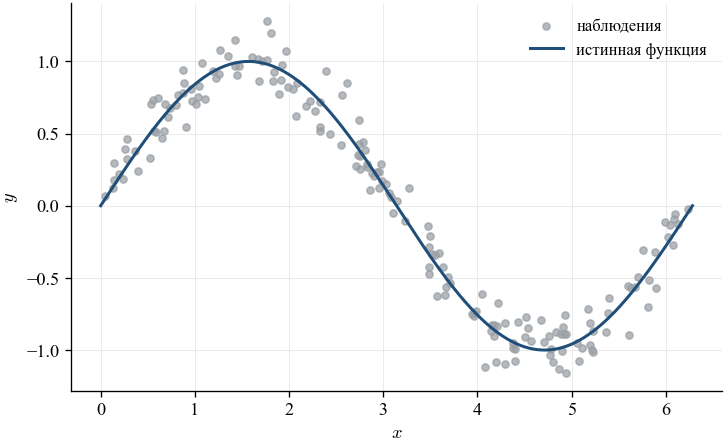

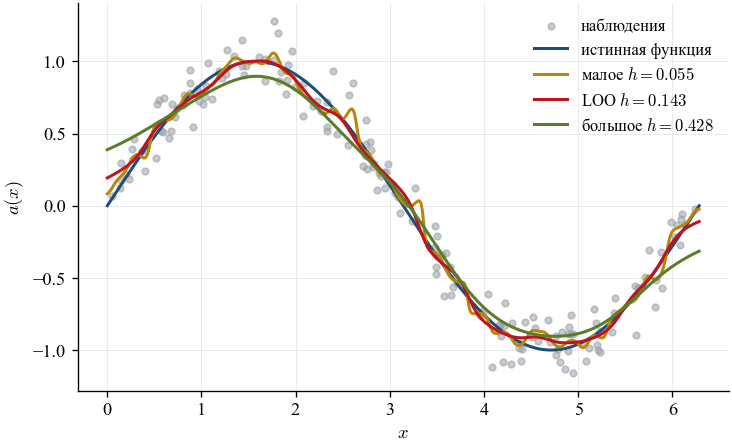

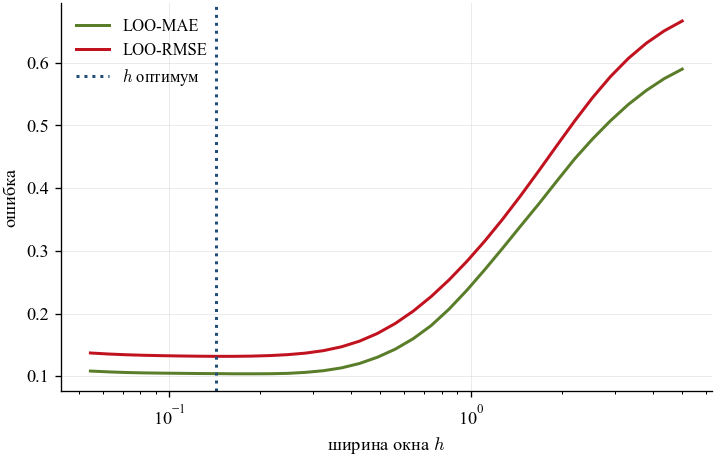

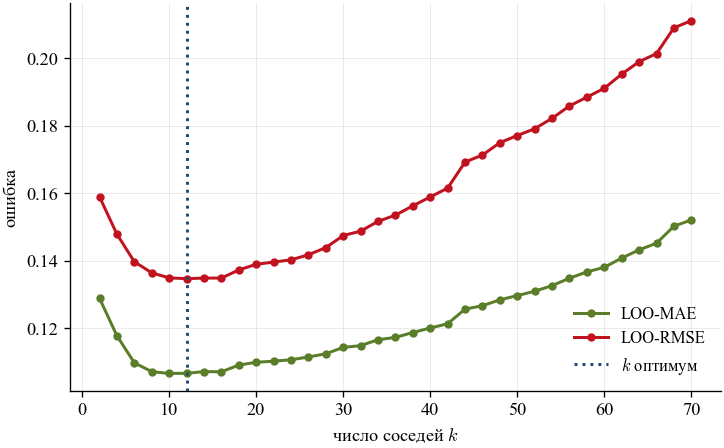

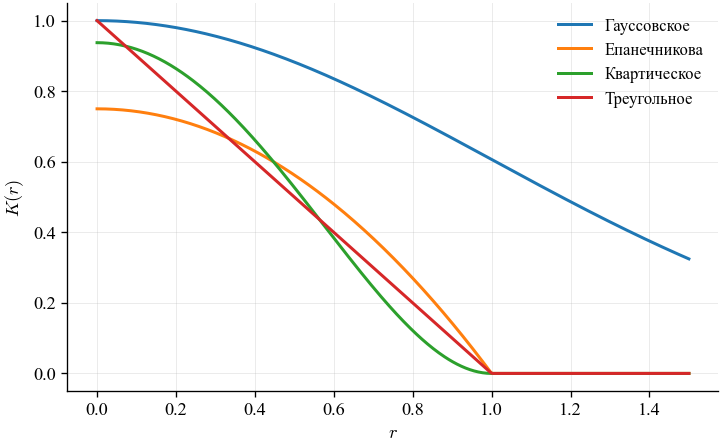

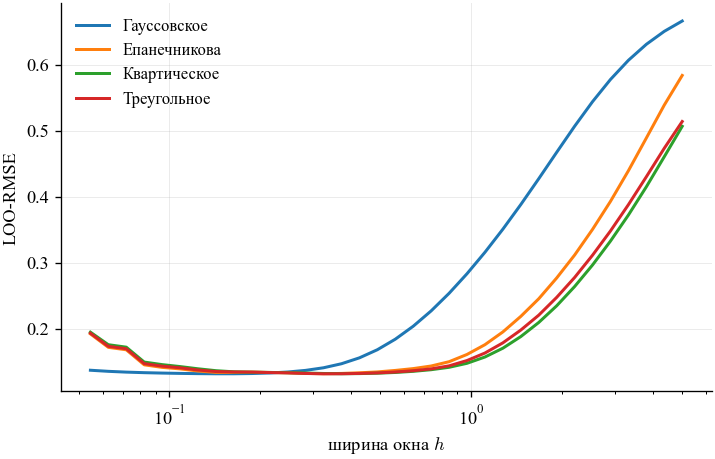

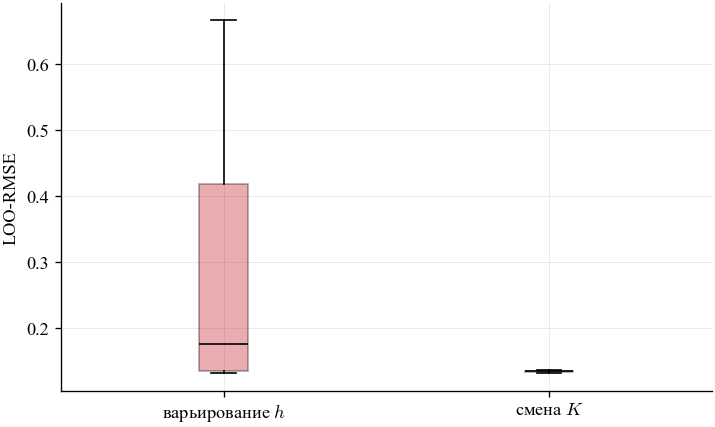

,Ядро,best_h,LOO_RMSE
0,Треугольное,0.323980,0.131681
1,Гауссовское,0.142529,0.131725
2,Епанечникова,0.323980,0.131805
3,Квартическое,0.371496,0.131815


In [11]:
rng = np.random.default_rng(SEED)
X_syn, y_syn, y_clean_syn, _ = generate_sine_data(N_SYNTH, SYNTH_NOISE, rng)
X_grid = np.linspace(0.0, 2.0 * np.pi, N_GRID).reshape(-1, 1)
y_grid = sine_function(X_grid)

h_grid = make_bandwidth_grid(X_syn, n_values=34)
best_h, gaussian_rmse_curve = select_bandwidth(X_syn, y_syn, gaussian_kernel, h_grid)
gaussian_mae_curve = np.array([loo_error(X_syn, y_syn, value, gaussian_kernel, metric="mae") for value in h_grid])

k_grid = make_k_grid(len(X_syn), max_k=70, step=2)
best_k_float, adaptive_rmse_curve = select_bandwidth(X_syn, y_syn, quartic_kernel, k_grid, adaptive=True)
best_k = int(best_k_float)
adaptive_mae_curve = np.array([loo_error(X_syn, y_syn, int(value), quartic_kernel, adaptive=True, metric="mae") for value in k_grid])

small_h = max(float(h_grid[0]), best_h / 3.0)
large_h = min(float(h_grid[-1]), best_h * 3.0)
bandwidth_predictions = {
    f"малое $h={small_h:.3f}$": nadaraya_watson_fixed(X_syn, y_syn, X_grid, small_h, gaussian_kernel),
    f"LOO $h={best_h:.3f}$": nadaraya_watson_fixed(X_syn, y_syn, X_grid, best_h, gaussian_kernel),
    f"большое $h={large_h:.3f}$": nadaraya_watson_fixed(X_syn, y_syn, X_grid, large_h, gaussian_kernel),
}

kernel_error_curves: dict[str, np.ndarray] = {}
best_rows: list[dict[str, float | str]] = []
for kernel_name, kernel in KERNELS.items():
    selected_h, curve = select_bandwidth(X_syn, y_syn, kernel, h_grid)
    kernel_error_curves[kernel_name] = curve
    best_rows.append({
        "Ядро": KERNEL_LABELS[kernel_name],
        "best_h": selected_h,
        "LOO_RMSE": float(np.min(curve)),
    })

tab_best_hyperparams = pd.DataFrame(best_rows).sort_values("LOO_RMSE", ignore_index=True)
save_table(tab_best_hyperparams, "tab_best_hyperparams")

save_fig(plot_synth_data(X_syn, y_syn, X_grid, y_grid), "fig_synth_data")
save_fig(plot_nw_bandwidth(X_syn, y_syn, X_grid, y_grid, bandwidth_predictions), "fig_nw_bandwidth")
save_fig(plot_error_vs_h(h_grid, gaussian_mae_curve, gaussian_rmse_curve, best_h), "fig_error_vs_h")
save_fig(plot_error_vs_k(k_grid, adaptive_mae_curve, adaptive_rmse_curve, best_k), "fig_error_vs_k")
save_fig(plot_kernels(np.linspace(0.0, 1.5, N_GRID)), "fig_kernels")
save_fig(plot_kernel_error(h_grid, kernel_error_curves), "fig_kernel_error")

window_error_range = float(np.max(gaussian_rmse_curve) - np.min(gaussian_rmse_curve))
kernels_at_fixed_h = np.array([loo_error(X_syn, y_syn, best_h, kernel, metric="rmse") for kernel in KERNELS.values()])
kernel_error_range = float(np.max(kernels_at_fixed_h) - np.min(kernels_at_fixed_h))
sensitivity_ratio = window_error_range / max(kernel_error_range, EPS)
save_fig(plot_kernel_vs_bandwidth(gaussian_rmse_curve, kernels_at_fixed_h), "fig_kernel_vs_bandwidth")

tab_best_hyperparams


## Эксперимент 2. Реальные датасеты

На Diabetes и California Housing сравниваются NW с фиксированным и переменным окном и LOWESS. Гиперпараметры подбираются по LOO-RMSE на обучающей части, качество измеряется на отложенном тесте (разбиение 70/30, seed 42).


In [12]:
def evaluate_real_dataset(
    dataset_name: str,
    X: np.ndarray,
    y: np.ndarray,
    *,
    sample_size: int | None,
    rng: np.random.Generator,
) -> tuple[list[dict[str, float | str]], dict[str, float]]:
    """Evaluate fixed NW, adaptive NW and LOWESS on one real dataset."""
    X_array = ensure_2d(X)
    y_array = np.asarray(y, dtype=float)
    if sample_size is not None and len(X_array) > sample_size:
        indices = rng.choice(len(X_array), size=sample_size, replace=False)
        X_array = X_array[indices]
        y_array = y_array[indices]
    X_train, X_test, y_train, y_test = train_test_split(
        X_array, y_array, test_size=0.30, random_state=SEED
    )
    X_train_std, X_test_std = standardize_train_test(X_train, X_test)
    h_grid_real = make_bandwidth_grid(X_train_std, n_values=13)
    k_grid_real = np.array([5, 9, 15, 25, 35, 50, 70], dtype=int)
    k_grid_real = k_grid_real[k_grid_real < max(len(X_train_std) - 2, 2)]
    if len(k_grid_real) == 0:
        k_grid_real = make_k_grid(len(X_train_std), max_k=20, step=3)

    best_h_real, fixed_curve = select_bandwidth(X_train_std, y_train, quartic_kernel, h_grid_real)
    best_k_real_float, adaptive_curve = select_bandwidth(X_train_std, y_train, quartic_kernel, k_grid_real, adaptive=True)
    best_k_real = int(best_k_real_float)

    fixed_pred = nadaraya_watson_fixed(X_train_std, y_train, X_test_std, best_h_real, quartic_kernel)
    adaptive_pred = nadaraya_watson_adaptive(X_train_std, y_train, X_test_std, best_k_real, quartic_kernel)
    gamma, _ = lowess_fit(X_train_std, y_train, k=best_k_real, kernel=quartic_kernel, n_iter=LOWESS_ITERATIONS)
    lowess_pred = lowess_predict(X_train_std, y_train, X_test_std, gamma, k=best_k_real, kernel=quartic_kernel)

    rows: list[dict[str, float | str]] = []
    for method_name, prediction in [
        ("NW фиксированное окно", fixed_pred),
        ("NW переменное окно", adaptive_pred),
        ("LOWESS", lowess_pred),
    ]:
        metrics = regression_metrics(y_test, prediction)
        rows.append({"Датасет": dataset_name, "Метод": method_name, **metrics})
    params = {
        "best_h": float(best_h_real),
        "best_k": float(best_k_real),
        "fixed_cv_rmse": float(np.min(fixed_curve)),
        "adaptive_cv_rmse": float(np.min(adaptive_curve)),
        "n_train": float(len(X_train_std)),
        "n_test": float(len(X_test_std)),
    }
    return rows, params

real_rng = np.random.default_rng(SEED + 100)
diabetes = load_diabetes()
real_rows, real_params = evaluate_real_dataset(
    "Diabetes",
    diabetes.data,
    diabetes.target,
    sample_size=None,
    rng=real_rng,
)

california = fetch_california_housing()
california_rows, california_params = evaluate_real_dataset(
    "California Housing",
    california.data,
    california.target,
    sample_size=REAL_SAMPLE_SIZE,
    rng=real_rng,
)
real_rows.extend(california_rows)
real_dataset_params = {
    "Diabetes": real_params,
    "California Housing": california_params,
}

tab_real_metrics = pd.DataFrame(real_rows)
save_table(tab_real_metrics, "tab_real_metrics")
tab_real_metrics


,Датасет,Метод,MAE,RMSE,R2
0,Diabetes,NW фиксированное окно,43.624281,54.886680,0.441946
1,Diabetes,NW переменное окно,42.669546,54.128935,0.457248
2,Diabetes,LOWESS,43.260396,54.877325,0.442136
3,California Housing,NW фиксированное окно,0.507109,0.718533,0.562664
4,California Housing,NW переменное окно,0.477397,0.681604,0.606462
5,California Housing,LOWESS,0.480488,0.706398,0.577311


## Эксперимент 3. Выбросы и робастность

Синтетическая выборка загрязняется крупными сдвигами ответа (доля выбросов 15%). Сравниваются обычная адаптивная ядерная регрессия и LOWESS по прогнозу, робастным весам $\gamma_i$ и распределению остатков.


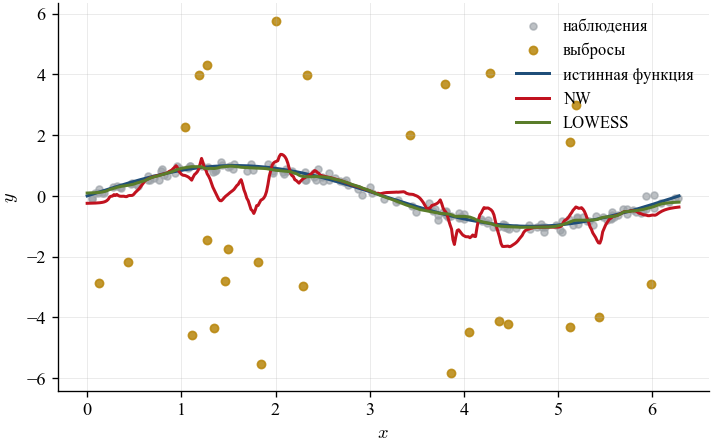

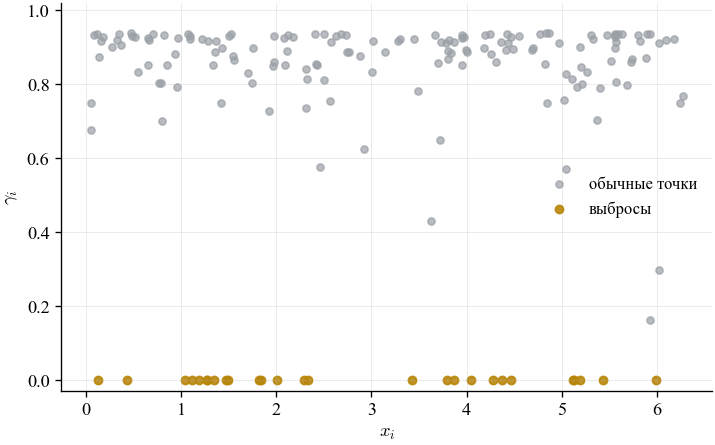

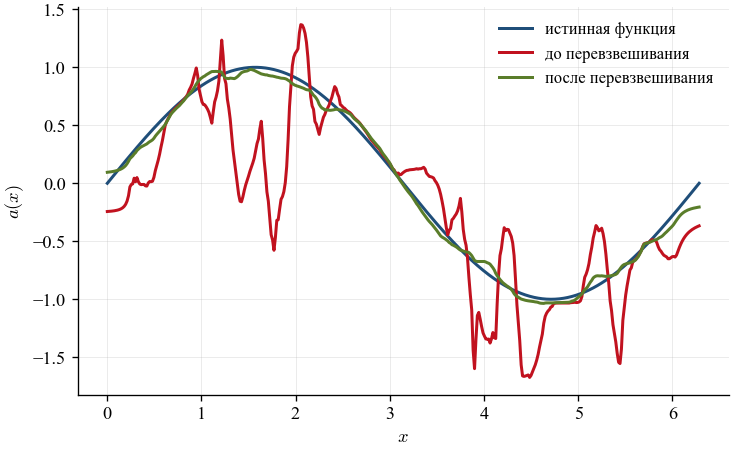

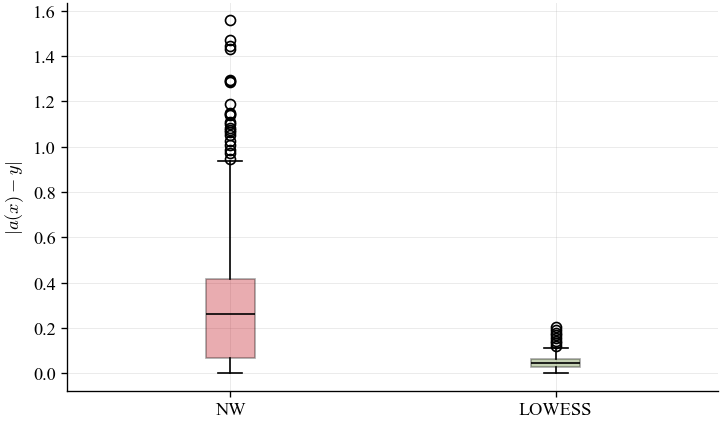

,Метод,MAE,RMSE,R2
0,NW переменное окно,0.307745,0.425191,0.637563
1,LOWESS,0.046769,0.055232,0.993884


In [13]:
outlier_rng = np.random.default_rng(SEED + 200)
X_out, y_out, y_out_clean, outlier_mask = generate_sine_data(
    N_SYNTH,
    SYNTH_NOISE,
    outlier_rng,
    outlier_fraction=OUTLIER_FRACTION,
    outlier_scale=OUTLIER_SCALE,
)
lowess_gamma, lowess_loo = lowess_fit(
    X_out,
    y_out,
    k=best_k,
    kernel=quartic_kernel,
    n_iter=LOWESS_ITERATIONS,
)

nw_out_pred = nadaraya_watson_adaptive(X_out, y_out, X_grid, best_k, quartic_kernel)
lowess_out_pred = lowess_predict(X_out, y_out, X_grid, lowess_gamma, k=best_k, kernel=quartic_kernel)

nw_residual = nw_out_pred - y_grid
lowess_residual = lowess_out_pred - y_grid
tab_outlier_metrics = pd.DataFrame([
    {"Метод": "NW переменное окно", **regression_metrics(y_grid, nw_out_pred)},
    {"Метод": "LOWESS", **regression_metrics(y_grid, lowess_out_pred)},
])
save_table(tab_outlier_metrics, "tab_outlier_metrics")

save_fig(plot_outliers_compare(X_out, y_out, outlier_mask, X_grid, y_grid, nw_out_pred, lowess_out_pred), "fig_outliers_compare")
save_fig(plot_lowess_weights(X_out, lowess_gamma, outlier_mask), "fig_lowess_weights")
save_fig(plot_lowess_before_after(X_grid, y_grid, nw_out_pred, lowess_out_pred), "fig_lowess_before_after")
save_fig(plot_error_distribution(nw_residual, lowess_residual), "fig_error_distribution")

tab_outlier_metrics


## Эксперимент 4. Порог загрязнения

Доля выбросов варьируется от 0% до 30%, каждая точка усредняется по четырём запускам. Определяется порог, начиная с которого LOWESS устойчиво превосходит обычное сглаживание.


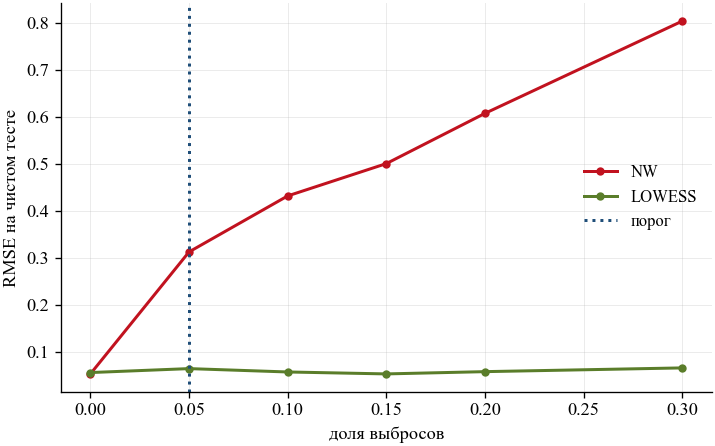

,outlier_fraction,nw_rmse,lowess_rmse,nw_std,lowess_std
0,0.00,0.052376,0.055287,0.006303,0.007195
1,0.05,0.312047,0.063690,0.043839,0.002718
2,0.10,0.431220,0.056534,0.010938,0.015101
3,0.15,0.499977,0.052400,0.080951,0.012424
4,0.20,0.606917,0.057235,0.063649,0.011820
5,0.30,0.803227,0.065195,0.047642,0.006609


In [14]:
contamination_rows: list[dict[str, float]] = []
for fraction in CONTAMINATION_LEVELS:
    nw_values: list[float] = []
    lowess_values: list[float] = []
    for repeat in range(CONTAMINATION_REPEATS):
        repeat_rng = np.random.default_rng(SEED + 1000 + repeat + int(round(fraction * 1000)))
        X_cont, y_cont, _, _ = generate_sine_data(
            N_SYNTH,
            SYNTH_NOISE,
            repeat_rng,
            outlier_fraction=float(fraction),
            outlier_scale=OUTLIER_SCALE,
        )
        gamma_cont, _ = lowess_fit(
            X_cont,
            y_cont,
            k=best_k,
            kernel=quartic_kernel,
            n_iter=LOWESS_ITERATIONS,
        )
        nw_pred = nadaraya_watson_adaptive(X_cont, y_cont, X_grid, best_k, quartic_kernel)
        lowess_pred = lowess_predict(X_cont, y_cont, X_grid, gamma_cont, k=best_k, kernel=quartic_kernel)
        nw_values.append(float(np.sqrt(mean_squared_error(y_grid, nw_pred))))
        lowess_values.append(float(np.sqrt(mean_squared_error(y_grid, lowess_pred))))
    contamination_rows.append({
        "outlier_fraction": float(fraction),
        "nw_rmse": float(np.mean(nw_values)),
        "lowess_rmse": float(np.mean(lowess_values)),
        "nw_std": float(np.std(nw_values)),
        "lowess_std": float(np.std(lowess_values)),
    })

contamination_df = pd.DataFrame(contamination_rows)
wins = contamination_df.loc[contamination_df["lowess_rmse"] < contamination_df["nw_rmse"], "outlier_fraction"]
contamination_threshold = float(wins.iloc[0]) if len(wins) else None
save_fig(plot_contamination(contamination_df, contamination_threshold), "fig_contamination")
contamination_df.to_csv(ASSETS_DIR / "contamination_curve.csv", index=False)
contamination_df


## Сводка результатов

Итоговые числовые показатели сохраняются в `case6_summary.json`; дополнительно проверяется наличие всех артефактов отчёта.


In [15]:
summary = {
    "best_h_gaussian": float(best_h),
    "best_k_adaptive": int(best_k),
    "best_kernel": str(tab_best_hyperparams.loc[0, "Ядро"]),
    "best_kernel_h": float(tab_best_hyperparams.loc[0, "best_h"]),
    "best_kernel_loo_rmse": float(tab_best_hyperparams.loc[0, "LOO_RMSE"]),
    "window_error_range": window_error_range,
    "kernel_error_range_at_fixed_h": kernel_error_range,
    "sensitivity_ratio_window_to_kernel": sensitivity_ratio,
    "contamination_threshold": contamination_threshold,
    "outlier_fraction_for_table": OUTLIER_FRACTION,
    "real_dataset_params": real_dataset_params,
    "seed": SEED,
    "n_synth": N_SYNTH,
    "real_sample_size": REAL_SAMPLE_SIZE,
}
with (ASSETS_DIR / "case6_summary.json").open("w", encoding="utf-8") as file:
    json.dump(summary, file, ensure_ascii=False, indent=2)

required_assets = [
    "fig_synth_data.svg",
    "fig_nw_bandwidth.svg",
    "fig_error_vs_h.svg",
    "fig_error_vs_k.svg",
    "fig_kernels.svg",
    "fig_kernel_error.svg",
    "fig_outliers_compare.svg",
    "fig_lowess_weights.svg",
    "fig_lowess_before_after.svg",
    "fig_error_distribution.svg",
    "fig_contamination.svg",
    "fig_kernel_vs_bandwidth.svg",
    "tab_best_hyperparams.csv",
    "tab_real_metrics.csv",
    "tab_outlier_metrics.csv",
]
missing_assets = [name for name in required_assets if not (ASSETS_DIR / name).exists()]
assert not missing_assets, missing_assets
pd.DataFrame([summary]).T.rename(columns={0: "Значение"})


,Значение
best_h_gaussian,0.142529
best_k_adaptive,12
best_kernel,Треугольное
best_kernel_h,0.32398
best_kernel_loo_rmse,0.131681
window_error_range,0.534482
kernel_error_range_at_fixed_h,0.004678
sensitivity_ratio_window_to_kernel,114.243738
contamination_threshold,0.05
outlier_fraction_for_table,0.15


## Выводы

Реализованы с нуля четыре ядра, евклидовы расстояния, оценка Надарая–Ватсона с фиксированным и переменным окном, LOO-подбор $h$ и $k$ и итерационная схема LOWESS. Эксперименты показывают, что ширина окна влияет на качество сильнее выбора ядра: после подбора $h$ все ядра дают почти одинаковую LOO-RMSE. Переменное окно выгодно при неоднородной плотности данных, что подтверждено на Diabetes и California Housing. LOWESS оправдан при наличии выбросов, найденный порог выигрыша составляет 5% загрязнения обучающей выборки.

Репозиторий: https://github.com/mezgou/itmo-functional-analysis-course
